# Gjeng
Vi kan definere en **gjeng** som et sett av noder som "henger sammen" men som henger løst sammen med resten; dersom en gjeng henger "godt" sammen med resten, da er resten en del av gjengen! 

Problemet er åpenbart: Hva betyr "henger sammen" og hva betyr "løst".

## Girvan-Newman

Vi kan bruke [Girvan-Newman](https://en.wikipedia.org/wiki/Girvan%E2%80%93Newman_algorithm) til å finne slike gjenger.  Algoritmen er basert på konseptet om en **bronode**.  En bronode er en node hvor mange korteste-sti (mellom andre noder) passerer gjennom.  Det gjør den sentral sett i lys av informasjonsspredning.  

Vi kan flytte fokus fra nodene til kantene, og sette vekt på kantene basert på hvor mange korteste-sti som går gjennom dem; en sti må naturligvis følge kanter like mye som noder.  Ved å fjerne kanter med høy vekt fragmenteres grafen, og gjengene står igjen.  De som først separeres ut er de som har bronoder som har få (men viktige) forbindelser til resten.

Kostnaden er $O(n^2k)$ hvor $n$ er antall noder og $k$ antall kanter.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
import numpy as np

G = nx.les_miserables_graph() # Innebygget


({'Myriel', 'Napoleon', 'Champtercier', 'Geborand', 'Cravatte', 'Count', 'MmeMagloire', 'OldMan', 'MlleBaptistine', 'CountessDeLo'}, {'Babet', 'Montparnasse', 'Claquesous', 'Gervais', 'Gribier', 'Champmathieu', 'Gillenormand', 'Boulatruelle', 'LtGillenormand', 'Combeferre', 'Fauchelevent', 'Bahorel', 'Pontmercy', 'Brevet', 'Simplice', 'MlleVaubois', 'MmeThenardier', 'Bossuet', 'Eponine', 'Grantaire', 'Marius', 'Gavroche', 'Child1', 'Woman2', 'Mabeuf', 'Magnon', 'Courfeyrac', 'Valjean', 'MmeHucheloup', 'Cochepaille', 'BaronessT', 'Toussaint', 'Thenardier', 'Cosette', 'MmePontmercy', 'Feuilly', 'MotherPlutarch', 'Brujon', 'Isabeau', 'Judge', 'Enjolras', 'Anzelma', 'Child2', 'Prouvaire', 'MlleGillenormand', 'MmeDeR', 'Joly', 'Woman1', 'Bamatabois', 'Gueulemer', 'Javert', 'MotherInnocent', 'Labarre', 'Scaufflaire', 'Chenildieu'}, {'Fantine', 'Listolier', 'Fameuil', 'Favourite', 'Marguerite', 'Dahlia', 'Perpetue', 'Tholomyes', 'Blacheville', 'Zephine'}, {'MmeBurgon', 'Jondrette'})


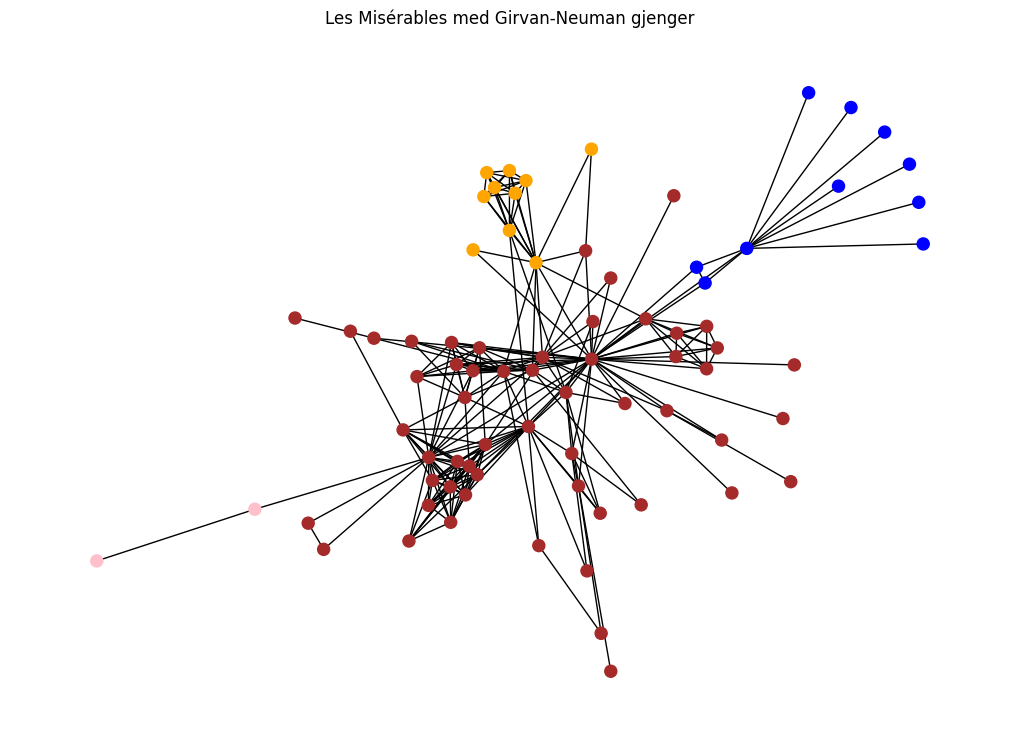

In [16]:
from networkx.algorithms.community import girvan_newman

# Denne deler grafen i stadig flere gjenger (itererer)
gjenger = girvan_newman(G)
første = next(gjenger)
andre = next(gjenger)
tredje = next(gjenger)
print(tredje)

fargeliste = ["blue", "brown", "orange", "pink"]

sett_id = {}
for snummer, s in enumerate(tredje):
    for e in s:
        sett_id[e] = snummer
    #
#
node_farge = []
for node in G:
    idx = sett_id.get(node)
    node_farge.append(fargeliste[idx])
#

# Tegne dem ved siden av hverandre
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=10)  # Beste jeg har funnet


pos = nx.spring_layout(G, seed=10) # Beste seed så langt
nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=75)
plt.title("Les Misérables med Girvan-Neuman gjenger")
plt.show()

SIste gjengen har bare to medlemmer.  Når vi se på grafen blir konklusjonen at det er et gaå mellom teori og virkelighet

## Louvain

Vi kan se på en gjeng som noder som er tettere knyttet til hverandre enn til resten (de andre nodene).  Det vil si at om vi tar utgangspunkt i en tilfeldig graf (se nedenfor) så vil det være flere kanten i en gjeng enn vi forventer; tettheten er større.

Noder flyttes inn i grupper, og man ser om tettheten "omkring" går opp eller ned når noden flyttes fra en gjeng til en annen.  Man sitter igjen med den optimale delingen i gjenger.

Ulempen er at gjengene er gjensidig utelukkende; neppe representativ for virkeligheten.  Videre, når to nærliggende klikker slås sammen kan det godt tenkes at det er "godt" for den overordnede inndelingen, men at de to i utgangspunktet var tett knyttet går tapt.

kjøretiden er kun $O(n \log n)$ og kan derfor brukes også på svært store grafer.
Info [på Wikipedia](https://en.wikipedia.org/wiki/Louvain_method).

Merke de viktigste nodene i hver gjeng.

Fant 6 gjenger
Lederne er: ['Myriel', 'Valjean', 'Fantine', 'Bamatabois', 'Thenardier', 'Gavroche']


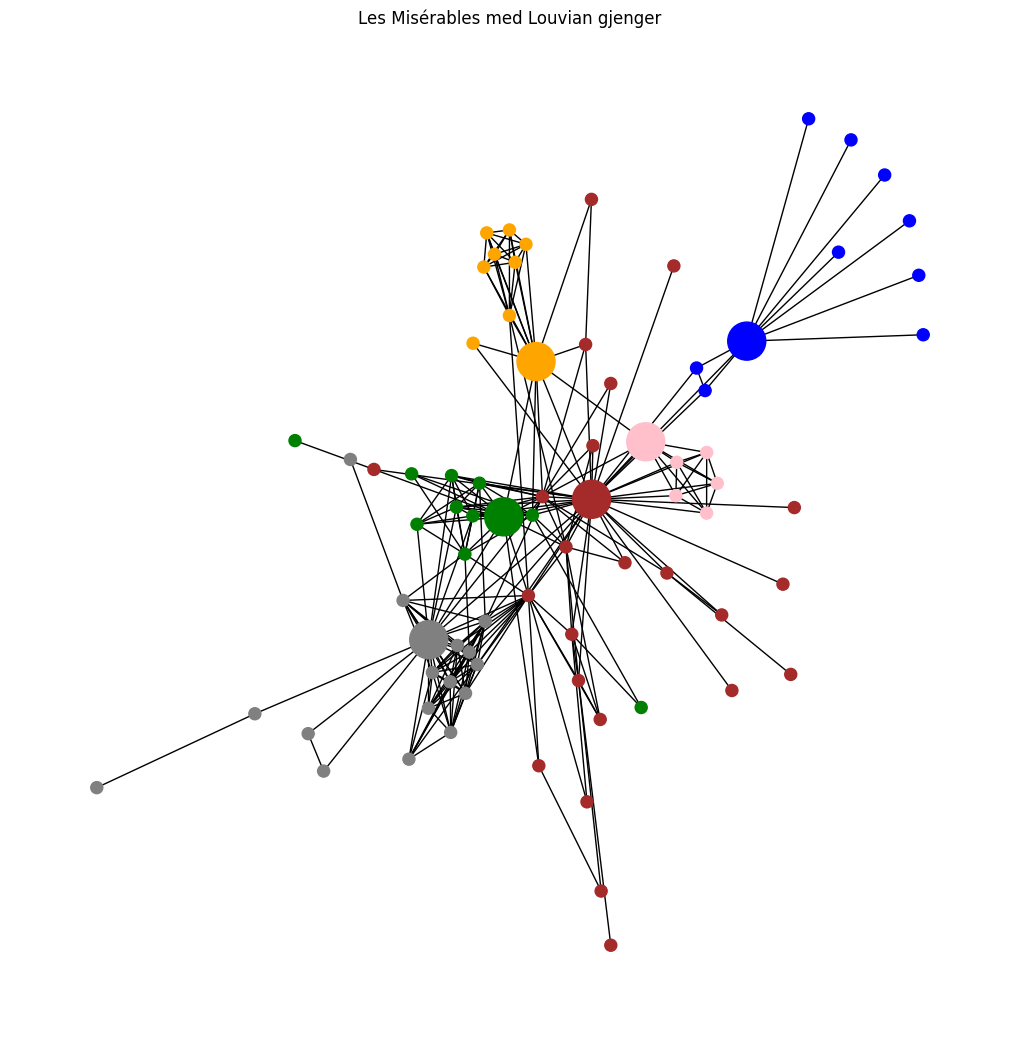

In [17]:
# Community detection with the Louvain Method
from networkx.algorithms.community import louvain_communities

# Calculate best partition for Louvain method
partitions = louvain_communities(G)
print(f"Fant {len(partitions)} gjenger")

# Finn de best forbundne i hver gjeng
ledere = []
for p in partitions:
    leder = max(p, key=lambda n:G.degree(n))
    ledere += [leder]
#
print(f"Lederne er: {ledere}")

# Håper det er færre gjenger enn det er farger
fargeliste = ["blue", "brown", "orange", "pink", "green", "gray", "red", "olive", "purple", "cyan"]
node_farge= []
størrelse = 75
node_størrelse = []
# Forutsetter at rekkefølgen er den samme hver gang
for node in G:
    # Hvilken partisjon er denne noden i?
    for idx, l in enumerate(partitions):
        if node in l:
            node_farge.append(fargeliste[idx])
            break
        #
    # Større noder for ledere
    if node in ledere:
        node_størrelse.append(størrelse* 10)
    else:
        node_størrelse.append(størrelse)
    #
#

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=10)
nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=node_størrelse)
plt.title("Les Misérables med Louvian gjenger")
plt.show()

## Epost-datasettet


In [18]:
import gzip

EG = nx.DiGraph()
# husk at gzip påpner i 'b'
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    for linje in fd:
         link = linje.split()
         EG.add_edge(int(link[0]), int(link[1]))
    #
#
# Bort med eposter sendt til seg selv
EG.remove_edges_from(nx.selfloop_edges(EG))
isolerte = list(nx.isolates(EG)) # kan ikke bruke iteratorer direkte
EG.remove_nodes_from(isolerte)
print(f"Antall noder etter isolerte: {EG.number_of_nodes()}")

Antall noder etter isolerte: 57189


In [21]:
# Vi konverterer til til en graf som ikke er rettet; om du sender eller mottar en epost 
# har du likevel en relasjon.  Legg merke til at dette reduserer antall kanter!
UG = EG.to_undirected(EG)
print(f"Antall noder: {UG.number_of_nodes()}")

Antall noder: 57189


In [22]:
# Tar noen sekunder
from networkx.algorithms.community import louvain_communities
partition = louvain_communities(UG)

# Hvor mange fant vi
print(f"Vi fant {len(partition)} gjenger")

Vi fant 283 gjenger


Se på den første gjengen

In [23]:
from ipysigma import Sigma
import math

# Hent den første
gjengen = UG.subgraph(partition[0])
print(gjengen)

# Størrelsen på nodene er log av antall (siden dette er en graf uten skala!)
log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Graph with 900 nodes and 1083 edges


Sigma(nx.Graph with 900 nodes and 1,083 edges)

La oss fjerne alle noder med mindre enn tre kanter (bladnoder).  Kanskje gir det oss et bedre bilde.

In [24]:
from ipysigma import Sigma
import math

gjengen = UG.subgraph(partition[0]).copy()
# Ta bort noder med mindre enn 3 kanter (de aller, aller fleste)
bladnoder = []
for n,d in gjengen.degree():
    if d < 3:
        bladnoder += [n]
    #
#

gjengen.remove_nodes_from(bladnoder)
log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 107 nodes and 244 edges)

## Konklusjon
Vi har sett på to av (svært) mange måter å definere og finne gjenger.  Det er mange utfordringer: Å vite om det vi har funnet er riktig, å "se" på det vi har funnet, hva lærer vi egentlig?

Vi blir helt avhengig av at koden vår gjør det vi tror, for vi kan ikke verifisere at resultatet er riktig!